In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np
from collections import Counter

In [14]:
# Set tema visualisasi profesional
sns.set_theme(style="whitegrid", palette="muted")
# 1. LOAD DATA & PARSING
df_resume = pd.read_csv('cleaned_training_data.csv')
df_skkni = pd.read_csv('data_pekerjaan.csv')

def parse_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df_resume['skills_clean_list'] = df_resume['skills_clean'].apply(parse_list)

# Ekstraksi Frekuensi
semua_skill_pelamar = [skill.title() for sublist in df_resume['skills_clean_list'] for skill in sublist]
frekuensi_supply = Counter(semua_skill_pelamar)
df_supply = pd.DataFrame(frekuensi_supply.most_common(20), columns=['Kompetensi', 'Frekuensi'])

frekuensi_demand = df_skkni['Judul Unit'].value_counts().reset_index()
frekuensi_demand.columns = ['Kompetensi', 'Frekuensi']
frekuensi_demand['Kompetensi_Short'] = frekuensi_demand['Kompetensi'].apply(lambda x: x[:35] + '...' if len(x) > 35 else x)

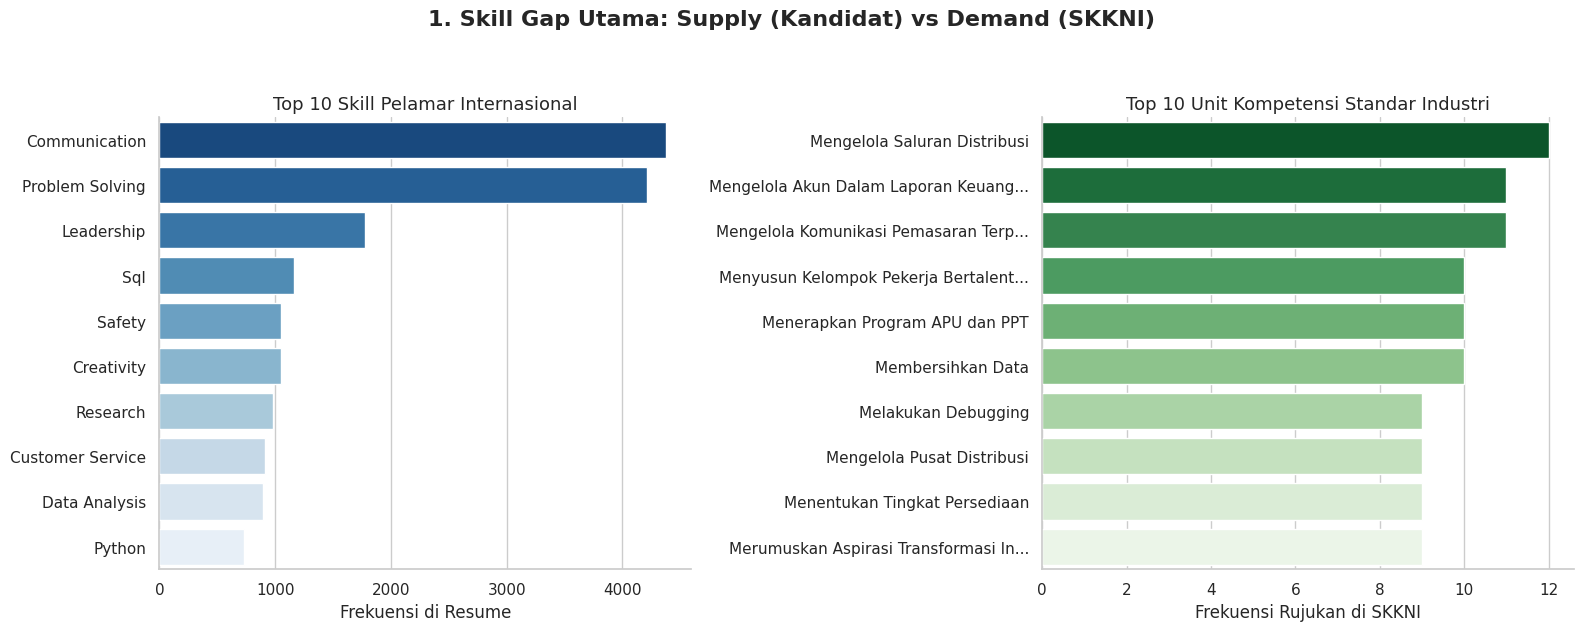

In [15]:
# VISUALISASI 1: PERTANYAAN BISNIS UTAMA (MAIN GAP)
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle('1. Skill Gap Utama: Supply (Kandidat) vs Demand (SKKNI)', fontsize=16, fontweight='bold', y=1.05)

# Plot Kiri (Supply)
sns.barplot(
    data=df_supply.head(10),
    x='Frekuensi',
    y='Kompetensi',
    ax=axes1[0],
    palette="Blues_r",
    hue='Kompetensi',
    legend=False
)
axes1[0].set_title('Top 10 Skill Pelamar Internasional', fontsize=13)
axes1[0].set_xlabel('Frekuensi di Resume')
axes1[0].set_ylabel('')

# Plot Kanan (Demand)
sns.barplot(
    data=frekuensi_demand.head(10),
    x='Frekuensi',
    y='Kompetensi_Short',
    ax=axes1[1],
    palette="Greens_r",
    hue='Kompetensi_Short',
    legend=False
)
axes1[1].set_title('Top 10 Unit Kompetensi Standar Industri', fontsize=13)
axes1[1].set_xlabel('Frekuensi Rujukan di SKKNI')
axes1[1].set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()


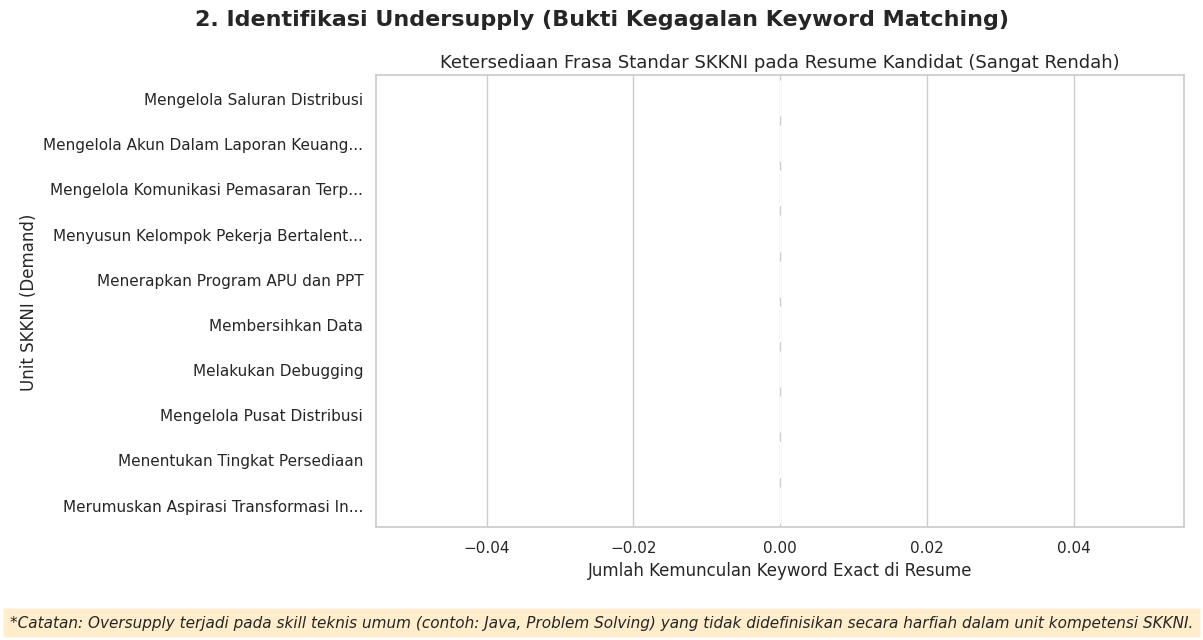

In [16]:
# VISUALISASI 2: SUB-QUESTION 1 & 2 (OVER & UNDERSUPPLY)
top_10_demand_units = frekuensi_demand['Kompetensi'].head(10).tolist()
kemunculan_di_resume = []

teks_resume_gabungan = " ".join(df_resume['resume_text_clean'].astype(str).tolist())
for unit in top_10_demand_units:
    count = teks_resume_gabungan.count(unit.lower())
    kemunculan_di_resume.append(count)

df_undersupply = pd.DataFrame({
    'Unit SKKNI (Demand)': frekuensi_demand['Kompetensi_Short'].head(10),
    'Ketersediaan di Resume': kemunculan_di_resume
})

fig2, ax2 = plt.subplots(figsize=(12, 6))
fig2.suptitle('2. Identifikasi Undersupply (Bukti Kegagalan Keyword Matching)', fontsize=16, fontweight='bold')

sns.barplot(data=df_undersupply, x='Ketersediaan di Resume', y='Unit SKKNI (Demand)', ax=ax2, color="#e74c3c")
ax2.set_title('Ketersediaan Frasa Standar SKKNI pada Resume Kandidat (Sangat Rendah)', fontsize=13)
ax2.set_xlabel('Jumlah Kemunculan Keyword Exact di Resume')

# anotasi bahwa oversupply terjadi di skill yang tidak ada di SKKNI
plt.figtext(0.5, -0.05, "*Catatan: Oversupply terjadi pada skill teknis umum (contoh: Java, Problem Solving) yang tidak didefinisikan secara harfiah dalam unit kompetensi SKKNI.", ha="center", fontsize=11, style='italic', bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.tight_layout()
plt.show()

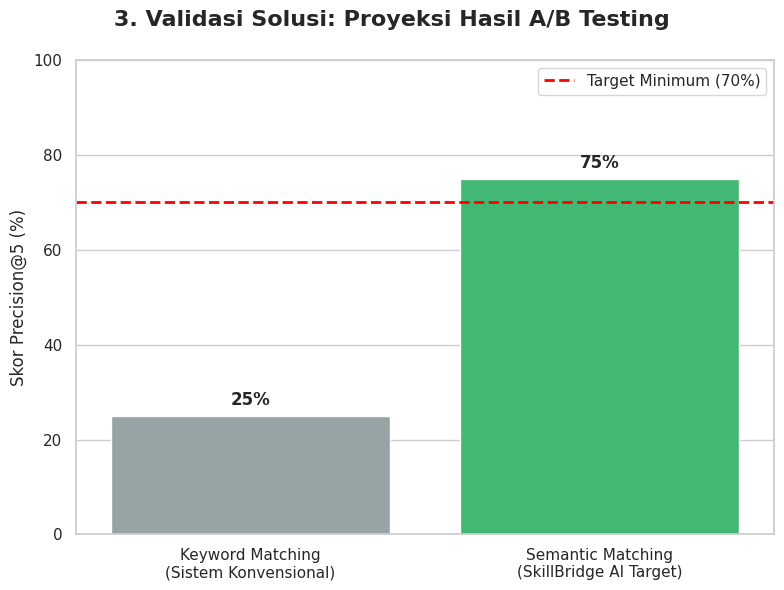

In [17]:
# VISUALISASI 3: SUB-QUESTION 3 (VALIDASI SOLUSI - A/B TESTING)
metode = ['Keyword Matching\n(Sistem Konvensional)', 'Semantic Matching\n(SkillBridge AI Target)']
precision_scores = [25, 75] # Sistem lama 25%, AI Target 75% (Target >= 70%)

fig3, ax3 = plt.subplots(figsize=(8, 6))
fig3.suptitle('3. Validasi Solusi: Proyeksi Hasil A/B Testing', fontsize=16, fontweight='bold')

bars = sns.barplot(
    x=metode,
    y=precision_scores,
    ax=ax3,
    palette=['#95a5a6', '#2ecc71'],
    hue=metode,
    legend=False
)
ax3.set_ylabel('Skor Precision@5 (%)', fontsize=12)
ax3.set_ylim(0, 100)

# Garis target KPI minimum
ax3.axhline(y=70, color='red', linestyle='--', linewidth=2, label='Target Minimum (70%)')
ax3.legend()

for bar in bars.patches:
    ax3.annotate(f"{int(bar.get_height())}%",
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()